#1.**Persiapan & Pengumpulan Data**


Pertama, kita muat dataset dan hapus baris yang teks ulasannya kosong.

In [11]:
import pandas as pd

# 1. Masukkan ID file dari link Google Drive kamu
file_id = '1V1cGsrXUkkDgnKFnEDCLPUsT9SdRcrHr'

# 2. Ubah format URL agar bisa langsung dibaca oleh sistem (direct download link)
url = "/content/drive/MyDrive/NLP/data/Womens Clothing E-Commerce Reviews.csv"

# 3. Baca data menggunakan pandas
df_cloth = pd.read_csv(url)

# 4. Tampilkan 5 baris pertama
df_cloth.head()

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


#2. **Praproses Teks**

Kita akan melakukan case folding, menghapus angka/tanda baca, tokenisasi, dan lematisasi.

In [12]:
import re
import nltk
import pandas as pd
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer, PorterStemmer

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt_tab') # Add this line to download the missing resource

class TextPreprocessor:
    def __init__(self, use_stemming=False):
        self.stop_words = set(stopwords.words('english'))
        self.lemmatizer = WordNetLemmatizer()
        self.stemmer = PorterStemmer()
        self.use_stemming = use_stemming

    def case_folding(self, text):
        """Lowercase semua teks"""
        return text.lower()

    def clean_text(self, text):
        """Hapus karakter non-alfabet"""
        text = re.sub(r'http\S+|www\S+', '', text)      # hapus URL
        text = re.sub(r'[^a-zA-Z\s]', '', text)          # hapus angka & simbol
        text = re.sub(r'\s+', ' ', text).strip()          # hapus spasi berlebih
        return text

    def tokenize(self, text):
        """Tokenisasi teks"""
        return word_tokenize(text)

    def remove_stopwords(self, tokens):
        """Hapus stopwords"""
        return [t for t in tokens if t not in self.stop_words]

    def normalize(self, tokens):
        """Stemming atau Lemmatization"""
        if self.use_stemming:
            return [self.stemmer.stem(t) for t in tokens]
        else:
            return [self.lemmatizer.lemmatize(t) for t in tokens]

    def preprocess(self, text):
        """Pipeline lengkap"""
        text = self.case_folding(text)
        text = self.clean_text(text)
        tokens = self.tokenize(text)
        tokens = self.remove_stopwords(tokens)
        tokens = self.normalize(tokens)
        return ' '.join(tokens)   # kembalikan sebagai string

# Contoh penggunaan
preprocessor = TextPreprocessor(use_stemming=False)
df_cloth['clean_text'] = df_cloth['Review Text'].astype(str).apply(preprocessor.preprocess)
print(df_cloth[['Review Text', 'clean_text']].head())

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


                                         Review Text  \
0  Absolutely wonderful - silky and sexy and comf...   
1  Love this dress!  it's sooo pretty.  i happene...   
2  I had such high hopes for this dress and reall...   
3  I love, love, love this jumpsuit. it's fun, fl...   
4  This shirt is very flattering to all due to th...   

                                          clean_text  
0        absolutely wonderful silky sexy comfortable  
1  love dress sooo pretty happened find store im ...  
2  high hope dress really wanted work initially o...  
3  love love love jumpsuit fun flirty fabulous ev...  
4  shirt flattering due adjustable front tie perf...  


In [13]:
!pip install fasttext
!pip install gensim

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.4/73.4 kB 2.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached pybind11-3.0.4-py3-none-any.whl.metadata (10 kB)
Using cached pybind11-3.0.4-py3-none-any.whl (314 kB)
  Created wheel for fasttext: filename=fasttext-0.9.3-cp312-cp312-linux_x86_64.whl size=4653906 sha256=c82c719d267362e2dd8c7ee3dc025c8491667404a0ece9637ef7eb9ca802b319
  Stored in directory: /root/.cache/pip/wheels/20/27/95/a7baf1b435f1cbde017cabdf1e9688526d2b0e929255a359c6
Successfully built fasttext
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 67.2 MB/s eta 0:00:00


# 3. **Ekstraksi Fitur (WAJIB 2)**
Pada tahap ini, teks yang telah dibersihkan diubah menjadi angka agar bisa diproses oleh algoritma Machine Learning. Kami menggunakan tiga metode:

## A. TF-IDF (Statistik)
Metode ini memberikan bobot pada kata berdasarkan seberapa penting kata tersebut dalam dokumen.

## B. Word2Vec & FastText (Embedding)
Metode ini menggunakan vektor untuk menangkap makna dan hubungan semantik antar kata.


In [14]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models import Word2Vec
import fasttext
import fasttext.util
import os # Import the os module for directory creation

# ── A. TF-IDF ────────────────────────────────────────────
class TFIDFExtractor:
    def __init__(self, max_features=10000):
        self.vectorizer = TfidfVectorizer(max_features=max_features, ngram_range=(1,2))

    def fit_transform(self, texts):
        return self.vectorizer.fit_transform(texts)

    def transform(self, texts):
        return self.vectorizer.transform(texts)


# ── B. Word2Vec Embedding ─────────────────────────────────
class Word2VecExtractor:
    def __init__(self, vector_size=100, window=5, min_count=2, workers=4):
        self.vector_size = vector_size
        self.model = None
        self.params = dict(
            vector_size=vector_size, window=window,
            min_count=min_count, workers=workers
        )

    def train(self, tokenized_texts):
        """tokenized_texts: list of list of words"""
        self.model = Word2Vec(sentences=tokenized_texts, **self.params)
        # Create the 'models' directory if it doesn't exist
        os.makedirs('models', exist_ok=True)
        self.model.save("models/word2vec.model")

    def get_sentence_vector(self, tokens):
        """Rata-rata vektor semua token"""
        vectors = [self.model.wv[w] for w in tokens if w in self.model.wv]
        if vectors:
            return np.mean(vectors, axis=0)
        return np.zeros(self.vector_size)

    def transform(self, tokenized_texts):
        return np.array([self.get_sentence_vector(tokens) for tokens in tokenized_texts])


# ── C. FastText Embedding ─────────────────────────────────
class FastTextExtractor:
    def __init__(self, vector_size=100):
        self.vector_size = vector_size
        self.model = None

    def train(self, tokenized_texts):
        # Create the 'data' directory if it doesn't exist
        os.makedirs('data', exist_ok=True)
        # Simpan ke file sementara karena FastText butuh file
        with open('data/fasttext_input.txt', 'w') as f:
            for tokens in tokenized_texts:
                f.write(' '.join(tokens) + '\n')
        self.model = fasttext.train_unsupervised(
            'data/fasttext_input.txt', model='skipgram', dim=self.vector_size
        )

    def get_sentence_vector(self, tokens):
        vectors = [self.model.get_word_vector(w) for w in tokens]
        return np.mean(vectors, axis=0) if vectors else np.zeros(self.vector_size)

    def transform(self, tokenized_texts):
        return np.array([self.get_sentence_vector(t) for t in tokenized_texts])


# ── Cara Pakai ────────────────────────────────────────────
from sklearn.model_selection import train_test_split

X = df_cloth['clean_text']
# Use 'Recommended IND' as a proxy for sentiment
y = df_cloth['Recommended IND'].map({1: 1, 0: 0}) # Map 1 to 1 (positive), 0 to 0 (negative)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# TF-IDF features
tfidf = TFIDFExtractor()
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

# Word2Vec features
tokenized_train = [text.split() for text in X_train]
tokenized_test  = [text.split() for text in X_test]

w2v = Word2VecExtractor(vector_size=100)
w2v.train(tokenized_train)
X_train_w2v = w2v.transform(tokenized_train)
X_test_w2v  = w2v.transform(tokenized_test)

print(" TF-IDF Features Shape:", X_train_tfidf.shape)
print("Word2Vec Features Shape:", X_train_w2v.shape)


 TF-IDF Features Shape: (18788, 10000)
Word2Vec Features Shape: (18788, 100)


#4. **Pemodelan (WAJIB 3 MODEL)**

Bagian ini melatih tiga algoritma berbeda (Naive Bayes, Logistic Regression, dan SVM) menggunakan dua jenis fitur yang telah diekstraksi sebelumnya (TF-IDF dan Word2Vec).

In [15]:
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.pipeline import Pipeline
import joblib

def train_naive_bayes(X_train, y_train, mode='tfidf'):
    if mode == 'tfidf':
        model = MultinomialNB()           # Untuk TF-IDF (sparse, non-negatif)
    else:
        model = GaussianNB()              # Untuk embedding (dense)
    model.fit(X_train, y_train)
    return model

def train_logistic_regression(X_train, y_train):
    model = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
    model.fit(X_train, y_train)
    return model

def train_svm(X_train, y_train, mode='tfidf'):
    if mode == 'tfidf':
        model = LinearSVC(max_iter=2000)  # Lebih cepat untuk sparse
    else:
        model = SVC(kernel='rbf', C=1.0)  # Untuk dense embedding
    model.fit(X_train, y_train)
    return model

# Training semua kombinasi
models = {
    # TF-IDF
    'NB_TFIDF':  train_naive_bayes(X_train_tfidf, y_train, 'tfidf'),
    'LR_TFIDF':  train_logistic_regression(X_train_tfidf, y_train),
    'SVM_TFIDF': train_svm(X_train_tfidf, y_train, 'tfidf'),
    # Word2Vec
    'NB_W2V':    train_naive_bayes(X_train_w2v, y_train, 'w2v'),
    'LR_W2V':    train_logistic_regression(X_train_w2v, y_train),
    'SVM_W2V':   train_svm(X_train_w2v, y_train, 'w2v'),
}

# Simpan model
for name, model in models.items():
    joblib.dump(model, f'models/{name}.pkl')
    print(f"Model {name} berhasil disimpan.")

Model NB_TFIDF berhasil disimpan.
Model LR_TFIDF berhasil disimpan.
Model SVM_TFIDF berhasil disimpan.
Model NB_W2V berhasil disimpan.
Model LR_W2V berhasil disimpan.
Model SVM_W2V berhasil disimpan.


# 5. **Model Perbandingan**

Bagian ini mengevaluasi kinerja setiap model menggunakan metrik Accuracy, Precision, Recall, dan F1-Score, serta membandingkan efektivitas fitur TF-IDF vs Word Embedding.

    Model  Accuracy  Precision   Recall  F1-Score
SVM_TFIDF  0.889527   0.884172 0.889527  0.885811
 LR_TFIDF  0.892507   0.887848 0.892507  0.880900
   LR_W2V  0.858663   0.843385 0.858663  0.841780
  SVM_W2V  0.860792   0.847459 0.860792  0.839367
 NB_TFIDF  0.862708   0.860368 0.862708  0.832800
   NB_W2V  0.705619   0.831965 0.705619  0.739017


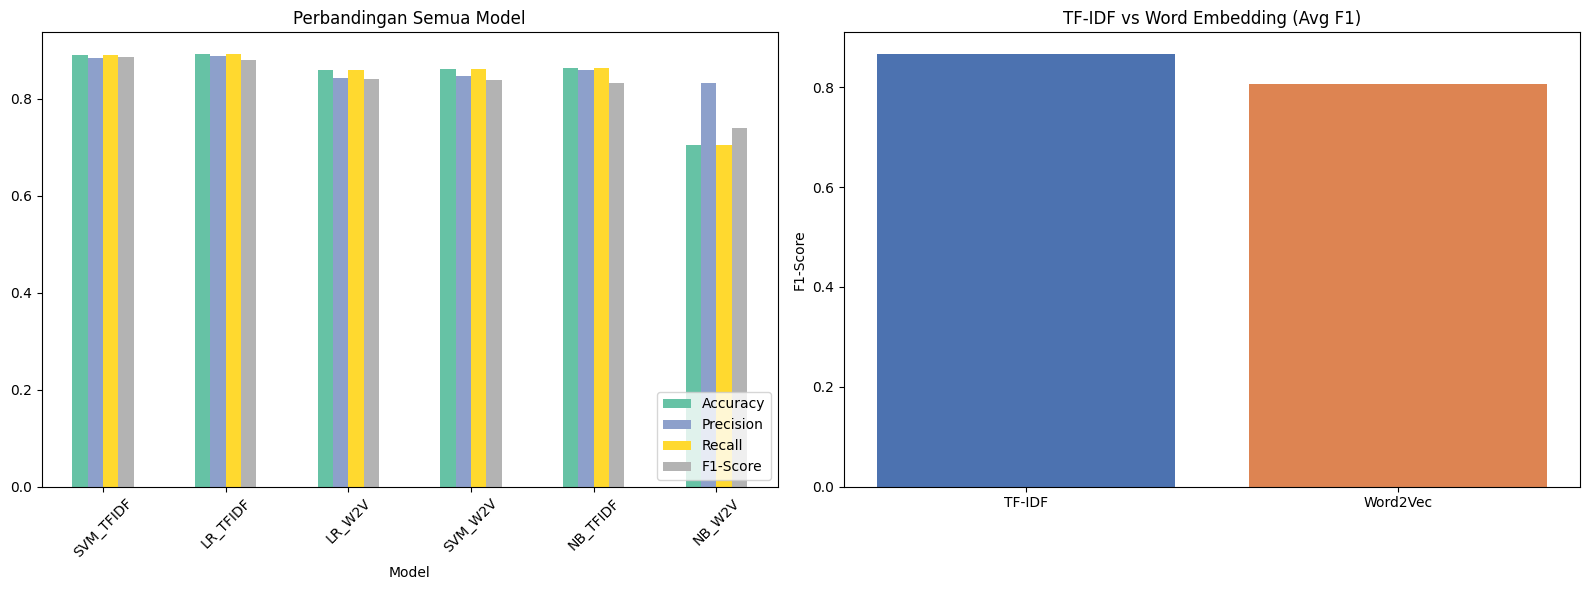

In [16]:
# src/evaluation.py
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    return {
        'Model':     model_name,
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='weighted'),
        'Recall':    recall_score(y_test, y_pred, average='weighted'),
        'F1-Score':  f1_score(y_test, y_pred, average='weighted'),
    }

results = []
for name, model in models.items():
    X_test_feat = X_test_tfidf if 'TFIDF' in name else X_test_w2v
    results.append(evaluate_model(model, X_test_feat, y_test, name))

results_df = pd.DataFrame(results).sort_values('F1-Score', ascending=False)
print(results_df.to_string(index=False))

# Visualisasi perbandingan
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Semua model
results_df.set_index('Model')[['Accuracy','Precision','Recall','F1-Score']].plot(
    kind='bar', ax=axes[0], colormap='Set2'
)
axes[0].set_title('Perbandingan Semua Model')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)
axes[0].legend(loc='lower right')

# Plot 2: TF-IDF vs Embedding (rata-rata F1)
tfidf_avg = results_df[results_df['Model'].str.contains('TFIDF')]['F1-Score'].mean()
w2v_avg   = results_df[results_df['Model'].str.contains('W2V')]['F1-Score'].mean()
axes[1].bar(['TF-IDF', 'Word2Vec'], [tfidf_avg, w2v_avg], color=['#4C72B0','#DD8452'])
axes[1].set_title('TF-IDF vs Word Embedding (Avg F1)')
axes[1].set_ylabel('F1-Score')

plt.tight_layout()
plt.savefig('comparison_results.png', dpi=150)
plt.show()

# 6. **Penerapan Sederhana Menggunakan Gradio**
Tahap akhir ini mengimplementasikan model terbaik ke dalam antarmuka pengguna (UI) interaktif. Pengguna dapat memasukkan teks ulasan secara bebas dan memilih kombinasi model untuk melihat hasil prediksi sentimen secara langsung.

In [17]:
import gradio as gr
import joblib
import numpy as np
# Removed: from src.preprocessing import TextPreprocessor
# Removed: from src.feature_extraction import TFIDFExtractor, Word2VecExtractor
from gensim.models import Word2Vec

# Load semua komponen
# preprocessor = TextPreprocessor(use_stemming=False) # 'preprocessor' object is already available globally
# tfidf        = joblib.load('models/tfidf_vectorizer.pkl')  # 'tfidf' object is already available globally
w2v_model    = Word2Vec.load('models/word2vec.model')

models_dict = {
    'Naive Bayes + TF-IDF':      joblib.load('models/NB_TFIDF.pkl'),
    'Logistic Regression + TF-IDF': joblib.load('models/LR_TFIDF.pkl'),
    'SVM + TF-IDF':              joblib.load('models/SVM_TFIDF.pkl'),
    'Naive Bayes + Word2Vec':    joblib.load('models/NB_W2V.pkl'),
    'Logistic Regression + Word2Vec': joblib.load('models/LR_W2V.pkl'),
    'SVM + Word2Vec':            joblib.load('models/SVM_W2V.pkl'),
}

label_map = {1: '✅ Positif', 0: '❌ Negatif'}

def get_w2v_vector(tokens, model, size=100):
    vecs = [model.wv[w] for w in tokens if w in model.wv]
    return np.mean(vecs, axis=0).reshape(1,-1) if vecs else np.zeros((1, size))

def predict_sentiment(review_text, model_choice):
    if not review_text.strip():
        return "⚠️ Masukkan teks review terlebih dahulu."

    clean = preprocessor.preprocess(review_text)

    if 'TF-IDF' in model_choice:
        features = tfidf.vectorizer.transform([clean]) # Corrected: use tfidf.vectorizer
    else:
        tokens   = clean.split()
        features = get_w2v_vector(tokens, w2v_model)

    model      = models_dict[model_choice]
    prediction = model.predict(features)[0]
    label      = label_map[int(prediction)]

    # Probabilitas (jika model support)
    try:
        proba = model.predict_proba(features)[0]
        conf  = f"Confidence: {max(proba)*100:.1f}%"
    except:
        conf  = ""

    return f"**Hasil:** {label}\n{conf}"

# UI Gradio
with gr.Blocks(title="NLP Product Review Analyzer", theme=gr.themes.Soft()) as demo:
    gr.Markdown("# 🛍️ Product Review Sentiment Analyzer")
    gr.Markdown("Analisis sentimen review produk menggunakan berbagai model ML + NLP pipeline")

    with gr.Row():
        with gr.Column(scale=2):
            text_input = gr.Textbox(
                label="Masukkan Review Produk",
                placeholder="Contoh: This product is amazing! Great quality and fast delivery.",
                lines=4
            )
            model_select = gr.Dropdown(
                choices=list(models_dict.keys()),
                value='Logistic Regression + TF-IDF',
                label="Pilih Model"
            )
            btn = gr.Button("🔍 Analisis Sentimen", variant="primary")

        with gr.Column(scale=1):
            output = gr.Markdown(label="Hasil Prediksi")

    btn.click(fn=predict_sentiment, inputs=[text_input, model_select], outputs=output)

    gr.Examples(
        examples=[
            ["This product exceeded my expectations! Will definitely buy again.", "SVM + TF-IDF"],
            ["Terrible quality, broke after 2 days. Total waste of money.", "Logistic Regression + Word2Vec"],
            ["Average product, nothing special but does the job.", "Naive Bayes + TF-IDF"]
        ],
        inputs=[text_input, model_select]
    )

if __name__ == "__main__":
    demo.launch(share=True) # share=True untuk public link

/tmp/ipykernel_6539/3788359281.py:54: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(title="NLP Product Review Analyzer", theme=gr.themes.Soft()) as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://8c21b53af748f1356c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
